# Проект: Обучение с учителем: качество модели  
  
  
# Описание проекта  
  
Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.  
  
«В один клик» — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, и нам предстоит побыть в роли стажёра в этом отделе.   
  
Итак, нашему отделу поручили разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.  
  
# Цель исследования  
  
Нужно построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.  
Используя данные модели и данные о прибыльности клиентов, нужно выделить сегменты покупателей и разработать для них персонализированные предложения.

# Краткий план исследования  
  
1. Загрузка и проверка данных
2. Предобработка данных
3. Исследовательский анализ данных
4. Объединение таблиц
5. Корреляционный анализ всех признаков
6. Использование пайплайнов
7. Анализ важности признаков
8. Сегментация покупателей
9. Общий вывод по исследованию

# Импортируем библиотеки

In [1]:
import pandas as pd
import numpy as np
!pip install matplotlib==3.5 -q
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import re

In [2]:
!pip install --upgrade scikit-learn -q
import sklearn
!pip install phik -q
import phik
!pip install shap -q
import shap

In [3]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

## Загрузим данные

In [4]:
df_market_file = pd.read_csv('/datasets/market_file.csv', sep=',')
df_market_money = pd.read_csv('/datasets/market_money.csv', sep=',')
df_market_time = pd.read_csv('/datasets/market_time.csv', sep=',')
df_money = pd.read_csv('/datasets/money.csv', sep=';')

In [5]:
display(df_market_file.head(15))
df_market_file.info()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандартт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4
6,215354,Снизилась,стандартт,да,5.1,3,431,0.23,Косметика и аксесуары,2,3,7,2
7,215355,Снизилась,стандартт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4
8,215356,Снизилась,стандартт,да,4.2,4,192,0.14,Косметика и аксесуары,2,2,1,3
9,215357,Снизилась,стандартт,да,3.9,5,154,0.00,Техника для красоты и здоровья,3,3,9,5


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1300 entries, 0 to 1299
,Data columns (total 13 columns):
, #   Column                               Non-Null Count  Dtype  
,---  ------                               --------------  -----  
, 0   id                                   1300 non-null   int64  
, 1   Покупательская активность            1300 non-null   object 
, 2   Тип сервиса                          1300 non-null   object 
, 3   Разрешить сообщать                   1300 non-null   object 
, 4   Маркет_актив_6_мес                   1300 non-null   float64
, 5   Маркет_актив_тек_мес                 1300 non-null   int64  
, 6   Длительность                         1300 non-null   int64  
, 7   Акционные_покупки                    1300 non-null   float64
, 8   Популярная_категория                 1300 non-null   object 
, 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
, 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
, 11  Ошибка_сервиса

In [6]:
display(df_market_money.head(15))
df_market_money.info()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6
5,215349,предыдущий_месяц,5216.0
6,215350,препредыдущий_месяц,4826.0
7,215350,текущий_месяц,5058.4
8,215350,предыдущий_месяц,5457.5
9,215351,текущий_месяц,6610.4


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 3900 entries, 0 to 3899
,Data columns (total 3 columns):
, #   Column   Non-Null Count  Dtype  
,---  ------   --------------  -----  
, 0   id       3900 non-null   int64  
, 1   Период   3900 non-null   object 
, 2   Выручка  3900 non-null   float64
,dtypes: float64(1), int64(1), object(1)
,memory usage: 91.5+ KB


In [7]:
display(df_market_time.head(15))
df_market_time.info()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13
5,215350,предыдцщий_месяц,8
6,215351,текущий_месяц,13
7,215351,предыдцщий_месяц,11
8,215352,текущий_месяц,11
9,215352,предыдцщий_месяц,8


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 2600 entries, 0 to 2599
,Data columns (total 3 columns):
, #   Column  Non-Null Count  Dtype 
,---  ------  --------------  ----- 
, 0   id      2600 non-null   int64 
, 1   Период  2600 non-null   object
, 2   минут   2600 non-null   int64 
,dtypes: int64(2), object(1)
,memory usage: 61.1+ KB


In [8]:
display(df_money.head(15))
df_money.info()

,id,Прибыль
0,215348,"0,98"
1,215349,"4,16"
2,215350,"3,13"
3,215351,"4,87"
4,215352,"4,21"
5,215353,"3,95"
6,215354,"3,62"
7,215355,"5,26"
8,215356,"4,93"
9,215357,"4,66"


<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1300 entries, 0 to 1299
,Data columns (total 2 columns):
, #   Column   Non-Null Count  Dtype 
,---  ------   --------------  ----- 
, 0   id       1300 non-null   int64 
, 1   Прибыль  1300 non-null   object
,dtypes: int64(1), object(1)
,memory usage: 20.4+ KB


**Вывод:**  
  
**Мы загрузили данные и вывели первые строки и общую информацию каждого датафрейма**  
  
1. **df_market_file:**  
  - В таблице 1300 записей и 13 столбцов, пропуски в данных отсутствуют.  
  - В данных столбца тип занятости есть опечатка. Нужно будет ее исправить.  
  - В датафрейме присутствуют такие данные, как:  
    - **id** - номер покупателя в корпоративной базе данных.
    - **Покупательская активность** - рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень».
    - **Тип сервиса** - уровень сервиса, например «премиум» и «стандарт».
    - **Разрешить сообщать** - информация о том, можно ли присылать покупателю дополнительные предложения о товаре. Согласие на это даёт покупатель.
    - **Маркет_актив_6_мес** - среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев. Это значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента.
    - **Маркет_актив_тек_мес** - количество маркетинговых коммуникаций в текущем месяце.
    - **Длительность** - значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте.
    - **Акционные_покупки** - среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев.
    - **Популярная_категория** - самая популярная категория товаров у покупателя за последние 6 месяцев.
    - **Средний_просмотр_категорий_за_визит** - показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца.
    - **Неоплаченные_продукты_штук_квартал** - общее число неоплаченных товаров в корзине за последние 3 месяца.
    - **Ошибка_сервиса** - число сбоев, которые коснулись покупателя во время посещения сайта.
    - **Страниц_за_визит** - среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца.
  
2. **df_market_money:**  
  - В таблице 3900 записей и 3 столбца, пропусков так же нет.
  - В датафрейме присутствуют такие данные, как: 
    - **id** - номер покупателя в корпоративной базе данных.
    - **Период** - название периода, во время которого зафиксирована выручка. Например, 'текущий_месяц' или 'предыдущий_месяц'.
    - **Выручка** - сумма выручки за период.
  
3. **df_market_time:**  
  - В таблице 2600 строк и 3 столбца, пропусков в данных нет.  
  - В столбце с периодом тоже есть опечатки в значениях.  
  - В датафрейме присутствуют такие данные, как:  
    - **id** - номер покупателя в корпоративной базе данных.
    - **Период** -  название периода, во время которого зафиксировано общее время.
    - **минут** -  значение времени, проведённого на сайте, в минутах.
  
4. **df_money:**  
  - В таблице 1300 строк и 2 столбца, пропуски отсутствуют.
  - В столбце с прибылью неверной указан тип данных, нужно будет сменить его с object на float64.
  - В датафрейме присутствуют такие данные, как:  
    - **id** - номер покупателя в корпоративной базе данных.
    - **Прибыль** - значение прибыли.

## Предобработка данных

Наименования столбцов в датафреймах оставим русскими, только в таблице **df_money** поменяем разделитель значений в столбце **"Прибыль"** с **","** на **"."**. Так же изменим тип данных в столбце **"Прибыль"** с **object** на **float64**.

In [9]:
df_money['Прибыль'] = df_money['Прибыль'].str.replace(',', '.').astype('float64')

### Найдем явные и неявные дубликаты

In [10]:
display(df_market_file.duplicated().sum())
display(df_market_money.duplicated().sum())
display(df_market_time.duplicated().sum())
df_money.duplicated().sum()

0

0

0

0

Явные дубликаты отсутствуют.

#### Проверим уникальные значения типа object во всех столбцах.

In [11]:
print('Уникальные значения в столбце "Покупательская активность":', df_market_file['Покупательская активность'].unique())
print('Уникальные значения в столбце "Тип сервиса":', df_market_file['Тип сервиса'].unique())
print('Уникальные значения в столбце "Разрешить сообщать":', df_market_file['Разрешить сообщать'].unique())
print('Уникальные значения в столбце "Популярная_категория":', df_market_file['Популярная_категория'].unique())

Уникальные значения в столбце "Покупательская активность": ['Снизилась' 'Прежний уровень']
,Уникальные значения в столбце "Тип сервиса": ['премиум' 'стандартт' 'стандарт']
,Уникальные значения в столбце "Разрешить сообщать": ['да' 'нет']
,Уникальные значения в столбце "Популярная_категория": ['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
, 'Техника для красоты и здоровья' 'Кухонная посуда'
, 'Мелкая бытовая техника и электроника']


В столбце с типом сервиса есть значение с опечаткой, исправим ее.

In [12]:
df_market_file['Тип сервиса'] = df_market_file['Тип сервиса'].str.replace('стандартт', 'стандарт')

In [13]:
print('Уникальные значения в столбце "Период":', df_market_money['Период'].unique())

Уникальные значения в столбце "Период": ['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']


В данном столбце нет опечаток и дубликатов.

In [14]:
print('Уникальные значения в столбце "Период":', df_market_time['Период'].unique())

Уникальные значения в столбце "Период": ['текущий_месяц' 'предыдцщий_месяц']


Здесь присутствует опечатка в значении 'предыдущий месяц'

In [15]:
df_market_time['Период'] = df_market_time['Период'].str.replace('предыдцщий_месяц', 'предыдущий_месяц')

**Проверим, не появились ли явные дубликаты в ходе исправлений и все ли теперь правильно указано.**

In [16]:
display(df_market_file.duplicated().sum())
display(df_market_money.duplicated().sum())
display(df_market_time.duplicated().sum())
df_money.duplicated().sum()

0

0

0

0

In [17]:
display(df_market_file.info())
display(df_market_money.info())
display(df_market_time.info())
df_money.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1300 entries, 0 to 1299
,Data columns (total 13 columns):
, #   Column                               Non-Null Count  Dtype  
,---  ------                               --------------  -----  
, 0   id                                   1300 non-null   int64  
, 1   Покупательская активность            1300 non-null   object 
, 2   Тип сервиса                          1300 non-null   object 
, 3   Разрешить сообщать                   1300 non-null   object 
, 4   Маркет_актив_6_мес                   1300 non-null   float64
, 5   Маркет_актив_тек_мес                 1300 non-null   int64  
, 6   Длительность                         1300 non-null   int64  
, 7   Акционные_покупки                    1300 non-null   float64
, 8   Популярная_категория                 1300 non-null   object 
, 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64  
, 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64  
, 11  Ошибка_сервиса

None

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 3900 entries, 0 to 3899
,Data columns (total 3 columns):
, #   Column   Non-Null Count  Dtype  
,---  ------   --------------  -----  
, 0   id       3900 non-null   int64  
, 1   Период   3900 non-null   object 
, 2   Выручка  3900 non-null   float64
,dtypes: float64(1), int64(1), object(1)
,memory usage: 91.5+ KB


None

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 2600 entries, 0 to 2599
,Data columns (total 3 columns):
, #   Column  Non-Null Count  Dtype 
,---  ------  --------------  ----- 
, 0   id      2600 non-null   int64 
, 1   Период  2600 non-null   object
, 2   минут   2600 non-null   int64 
,dtypes: int64(2), object(1)
,memory usage: 61.1+ KB


None

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1300 entries, 0 to 1299
,Data columns (total 2 columns):
, #   Column   Non-Null Count  Dtype  
,---  ------   --------------  -----  
, 0   id       1300 non-null   int64  
, 1   Прибыль  1300 non-null   float64
,dtypes: float64(1), int64(1)
,memory usage: 20.4 KB


**Вывод:**  
  
Мы устранили все опечатки и ошибки в данных. Явных дубликатов нет, пропуски тоже отсутствуют. Судя по данным везде количество клиентов одинаковое, просто где-то записей больше в 2-3 раза, поскольку по каждому клиенту информация указана например за 3 периода. Для объединения данных будем за основу брать столбец с id клиентов.

**Так же приведем названия столбцов к нижнему регистру.**

In [18]:
df_market_file.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', i).lower() for i in df_market_file.columns]
df_market_time.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', i).lower() for i in df_market_time.columns]
df_market_money.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', i).lower() for i in df_market_money.columns]
df_money.columns = [re.sub(r'(?<!^)(?=[A-Z])', '_', i).lower() for i in df_money.columns]
display(df_market_file.info())
display(df_market_time.info())
display(df_market_money.info())
df_money.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1300 entries, 0 to 1299
,Data columns (total 13 columns):
, #   Column                               Non-Null Count  Dtype  
,---  ------                               --------------  -----  
, 0   id                                   1300 non-null   int64  
, 1   покупательская активность            1300 non-null   object 
, 2   тип сервиса                          1300 non-null   object 
, 3   разрешить сообщать                   1300 non-null   object 
, 4   маркет_актив_6_мес                   1300 non-null   float64
, 5   маркет_актив_тек_мес                 1300 non-null   int64  
, 6   длительность                         1300 non-null   int64  
, 7   акционные_покупки                    1300 non-null   float64
, 8   популярная_категория                 1300 non-null   object 
, 9   средний_просмотр_категорий_за_визит  1300 non-null   int64  
, 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64  
, 11  ошибка_сервиса

None

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 2600 entries, 0 to 2599
,Data columns (total 3 columns):
, #   Column  Non-Null Count  Dtype 
,---  ------  --------------  ----- 
, 0   id      2600 non-null   int64 
, 1   период  2600 non-null   object
, 2   минут   2600 non-null   int64 
,dtypes: int64(2), object(1)
,memory usage: 61.1+ KB


None

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 3900 entries, 0 to 3899
,Data columns (total 3 columns):
, #   Column   Non-Null Count  Dtype  
,---  ------   --------------  -----  
, 0   id       3900 non-null   int64  
, 1   период   3900 non-null   object 
, 2   выручка  3900 non-null   float64
,dtypes: float64(1), int64(1), object(1)
,memory usage: 91.5+ KB


None

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1300 entries, 0 to 1299
,Data columns (total 2 columns):
, #   Column   Non-Null Count  Dtype  
,---  ------   --------------  -----  
, 0   id       1300 non-null   int64  
, 1   прибыль  1300 non-null   float64
,dtypes: float64(1), int64(1)
,memory usage: 20.4 KB


## Исследовательский анализ данных

### Выведем статистические данные по всем численным признакам, после построим гистограмы и "ящики с усами" и круговые диаграммы.

In [19]:
display(df_market_file[['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 
   'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 
   'ошибка_сервиса', 'страниц_за_визит']].describe())

,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.00000,1300.000000,1300.000000,1300.000000
mean,4.253769,4.011538,601.898462,0.319808,3.27000,2.840000,4.185385,8.176923
std,1.014814,0.696868,249.856289,0.249843,1.35535,1.971451,1.955298,3.978126
min,0.900000,3.000000,110.000000,0.000000,1.00000,0.000000,0.000000,1.000000
25%,3.700000,4.000000,405.500000,0.170000,2.00000,1.000000,3.000000,5.000000
50%,4.200000,4.000000,606.000000,0.240000,3.00000,3.000000,4.000000,8.000000
75%,4.900000,4.000000,806.000000,0.300000,4.00000,4.000000,6.000000,11.000000
max,6.600000,5.000000,1079.000000,0.990000,6.00000,10.000000,9.000000,20.000000


In [20]:
display(df_market_money['выручка'].describe())

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: выручка, dtype: float64

In [21]:
display(df_market_time['минут'].describe())

count    2600.000000
mean       13.336154
std         4.080198
min         4.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        23.000000
Name: минут, dtype: float64

In [22]:
display(df_money['прибыль'].describe())

count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64

**Вывод:**  
  
Судя по показателям во всех данных датафреймов распределения довольно нормальные, везде медиана довольно близка с средним значением. Лишь в столбце с выручкой датафрейма df_market_money есть довольно высокое максимальное значение, дальше на графиках увидим подробнее, как оно влияет на качество данных.

In [23]:
def df_visualization(df):
    for column in df.columns:
        column_type = df[column].dtype
        
        if column_type in ['int64', 'float64'] and column !='id':
            fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize=(10, 5))
            axes = axes.ravel()
            sns.histplot(data = df[column], kde=True, bins = 30, ax=axes[0])
            axes[0].set_title(column)
            mean = df[column].mean()
            axes[0].axvline(mean, color = 'red', linestyle = '-', label = f'Mean: {mean:.2f}' )
            median = df[column].median()
            axes[0].axvline(median, color = 'yellow', linestyle = '--', label = f'Median: {median:.2f}')
            axes[0].legend()
            axes[0].legend(loc = 'upper right')
            
            sns.boxplot(x=df[column], ax=axes[1])
            axes[1].set_title(f'{column}')
            axes[1].set_xlabel(column)
            plt.show()

In [24]:
def df_visualization2(df):
    for column in df.columns:
        column_type = df[column].dtypes
        
        if column_type == 'object':
            value_counts = df[column].value_counts()
            value_counts.plot.pie(autopct='%1.2f%%')
            plt.title(f'{column}')
            plt.show()

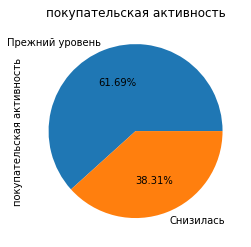

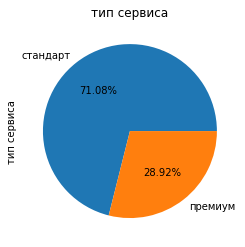

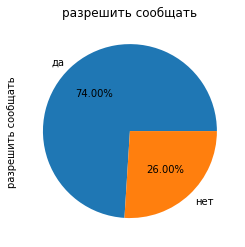

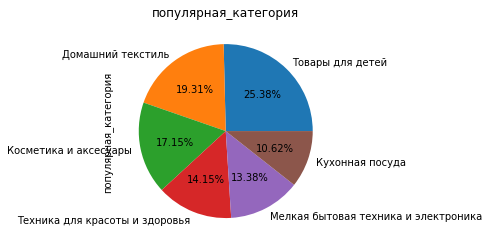

In [26]:
df_visualization2(df_market_file)

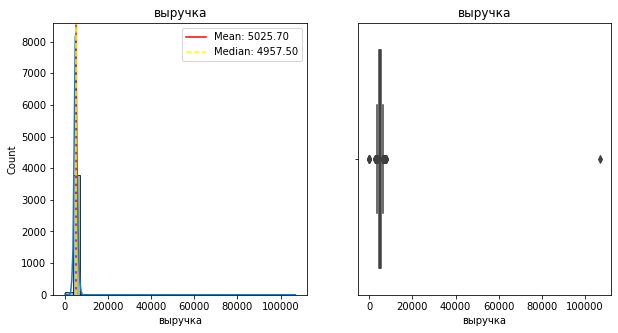

None

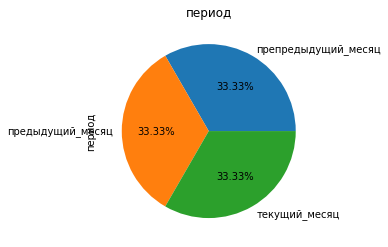

In [27]:
display(df_visualization(df_market_money))
df_visualization2(df_market_money)

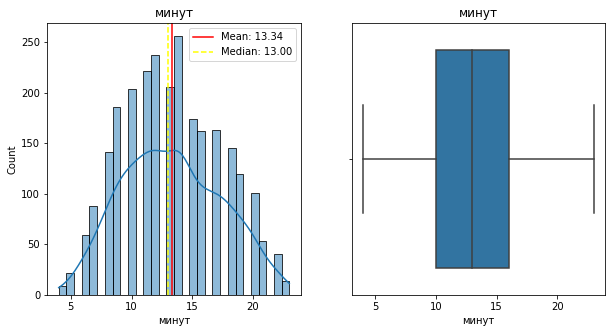

None

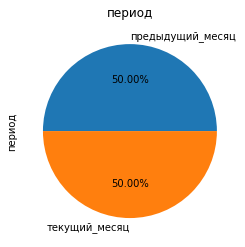

In [28]:
display(df_visualization(df_market_time))
df_visualization2(df_market_time)

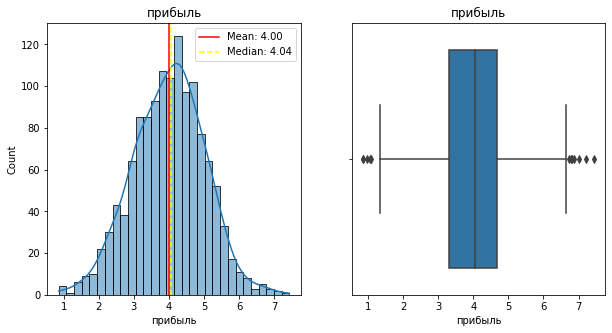

In [29]:
df_visualization(df_money)

**Вывод:**  
  
Мы вывели гистограммы и "ящики с усами" по всем количественным признакам и круговые диаграммы по категориальным признакам. Во всех графиках довольно нормальное распределение, где-то присутствует распределение Пуассона. В датафрейме df_market_money в столбце "Выручка" присутствует явный выброс, думаю, стоит удалить во всех таблицах данного клиента, чтобы в дальнейшем эти данные не сказались плохо на результатах.

count      3900.000000
mean       5025.696051
std        1777.704104
min           0.000000
25%        4590.150000
50%        4957.500000
75%        5363.000000
max      106862.200000
Name: выручка, dtype: float64

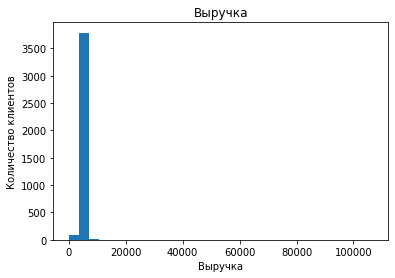

In [30]:
display(df_market_money['выручка'].describe())
df_market_money['выручка'].plot.hist(bins=30)
plt.title('Выручка')
plt.xlabel('Выручка')
plt.ylabel('Количество клиентов')
plt.show()

In [31]:
drop_id = df_market_money[df_market_money['выручка'] == 106862.2]['id']
df_market_file = df_market_file[~df_market_file['id'].isin(drop_id)]
df_market_money = df_market_money[~df_market_money['id'].isin(drop_id)]
df_market_time = df_market_time[~df_market_time['id'].isin(drop_id)]
df_money = df_money[~df_money['id'].isin(drop_id)]

In [32]:
df_market_file.info()
df_market_money.info()
df_market_time.info()
df_money.info()

<class 'pandas.core.frame.DataFrame'>
,Int64Index: 1299 entries, 0 to 1299
,Data columns (total 13 columns):
, #   Column                               Non-Null Count  Dtype  
,---  ------                               --------------  -----  
, 0   id                                   1299 non-null   int64  
, 1   покупательская активность            1299 non-null   object 
, 2   тип сервиса                          1299 non-null   object 
, 3   разрешить сообщать                   1299 non-null   object 
, 4   маркет_актив_6_мес                   1299 non-null   float64
, 5   маркет_актив_тек_мес                 1299 non-null   int64  
, 6   длительность                         1299 non-null   int64  
, 7   акционные_покупки                    1299 non-null   float64
, 8   популярная_категория                 1299 non-null   object 
, 9   средний_просмотр_категорий_за_визит  1299 non-null   int64  
, 10  неоплаченные_продукты_штук_квартал   1299 non-null   int64  
, 11  ошибка_сервиса

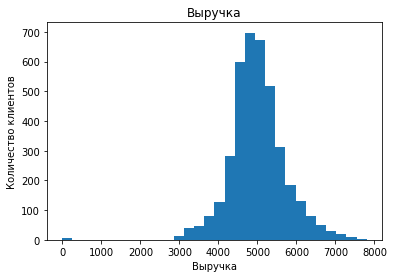

In [33]:
df_market_money['выручка'].plot.hist(bins=30)
plt.title('Выручка')
plt.xlabel('Выручка')
plt.ylabel('Количество клиентов')
plt.show()

Клиента с аномальным значением в показателе "Выручка" убрали из всех датафреймов. 

### Теперь отберем клиентов с покупательской активностью не менее трёх месяцев

Данные о клиентах с покупательской активностью указаны только в одном датафрейме, это df_market_money. В нем есть такие признаки, как "Выручка" и "Период". Проверим, присутствуют ли клиенты с недостаточной покупательской активностью.

In [34]:
df_market_money[df_market_money['выручка'] == 0]

,id,период,выручка
0,215348,препредыдущий_месяц,0.0
2,215348,предыдущий_месяц,0.0
28,215357,препредыдущий_месяц,0.0
29,215357,предыдущий_месяц,0.0
34,215359,предыдущий_месяц,0.0
35,215359,препредыдущий_месяц,0.0


Всего 3 клиента, которые за последние 3 месяца не принесли прибыли. Поскольку в дальнейшем исследовании эти клиенты бесполезны, то стоит исключить их из данных.

In [35]:
drop_id2 = [215348, 215357, 215359]
df_market_file = df_market_file[~df_market_file['id'].isin(drop_id2)]
df_market_money = df_market_money[~df_market_money['id'].isin(drop_id2)]
df_market_time = df_market_time[~df_market_time['id'].isin(drop_id2)]
df_money = df_money[~df_money['id'].isin(drop_id2)]

In [36]:
df_market_file.info()
df_market_money.info()
df_market_time.info()
df_money.info()

<class 'pandas.core.frame.DataFrame'>
,Int64Index: 1296 entries, 1 to 1299
,Data columns (total 13 columns):
, #   Column                               Non-Null Count  Dtype  
,---  ------                               --------------  -----  
, 0   id                                   1296 non-null   int64  
, 1   покупательская активность            1296 non-null   object 
, 2   тип сервиса                          1296 non-null   object 
, 3   разрешить сообщать                   1296 non-null   object 
, 4   маркет_актив_6_мес                   1296 non-null   float64
, 5   маркет_актив_тек_мес                 1296 non-null   int64  
, 6   длительность                         1296 non-null   int64  
, 7   акционные_покупки                    1296 non-null   float64
, 8   популярная_категория                 1296 non-null   object 
, 9   средний_просмотр_категорий_за_визит  1296 non-null   int64  
, 10  неоплаченные_продукты_штук_квартал   1296 non-null   int64  
, 11  ошибка_сервиса

### Общий вывод по исследовательскому анализу  
  
Мы провели анализ всех признаков во всех датафреймах, вывели гистограммы, "ящики с усами" и круговые диаграммы.  
  
Распределение большинства данных соответствует нормальному. Некоторые количественные признаки имеют распределение Пуассона. Так же из данных были удалены 4 клиента, 3 из которых за последние 3 месяца принесли сервису нулевую выручку, другой же клиент был исключен из данных по причине наличия аномального значения в признаке "Выручка".  
  
При анализе круговых диаграмм было замечено, что распределение некоторых категориальных признаков соответствует соотношению 1:3. Соотношение остальных признаков равномерное.

## Объединение таблиц

В основном датафрейме df_market_file всего 1296 строк, в df_market_money 3888 строк и в df_market_time 2592. Чтобы объединить эти датафреймы, их нужно привести к общему количеству строк.

In [37]:
df_market_money = df_market_money.pivot_table(index='id', columns='период', values='выручка')
df_market_money.columns = ['выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'выручка_текущий_месяц']
df_market_money.head(10)

,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
id,,,
215349,5216.0,4472.0,4971.6
215350,5457.5,4826.0,5058.4
215351,6158.0,4793.0,6610.4
215352,5807.5,4594.0,5872.5
215353,4738.5,5124.0,5388.5
215354,5685.0,4503.0,5869.6
215355,3263.0,4749.0,3772.6
215356,4146.5,4433.0,4566.4
215358,3488.0,4727.0,4209.5


In [38]:
df_market_time = df_market_time.pivot_table(index='id', columns='период', values='минут')
df_market_time.columns = ['минуты_предыдущий_месяц', 'минуты_текущий_месяц']
df_market_time.head(10)

,минуты_предыдущий_месяц,минуты_текущий_месяц
id,,
215349,12,10
215350,8,13
215351,11,13
215352,8,11
215353,10,10
215354,11,12
215355,12,10
215356,6,7
215358,14,10


In [39]:
merged_df = df_market_file.merge(df_market_money, on='id', how='inner')
display(merged_df.info())
merged_df.head()

<class 'pandas.core.frame.DataFrame'>
,Int64Index: 1296 entries, 0 to 1295
,Data columns (total 16 columns):
, #   Column                               Non-Null Count  Dtype  
,---  ------                               --------------  -----  
, 0   id                                   1296 non-null   int64  
, 1   покупательская активность            1296 non-null   object 
, 2   тип сервиса                          1296 non-null   object 
, 3   разрешить сообщать                   1296 non-null   object 
, 4   маркет_актив_6_мес                   1296 non-null   float64
, 5   маркет_актив_тек_мес                 1296 non-null   int64  
, 6   длительность                         1296 non-null   int64  
, 7   акционные_покупки                    1296 non-null   float64
, 8   популярная_категория                 1296 non-null   object 
, 9   средний_просмотр_категорий_за_визит  1296 non-null   int64  
, 10  неоплаченные_продукты_штук_квартал   1296 non-null   int64  
, 11  ошибка_сервиса

None

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5


In [40]:
df = merged_df.merge(df_market_time, on='id', how='inner')
display(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
,Int64Index: 1296 entries, 0 to 1295
,Data columns (total 18 columns):
, #   Column                               Non-Null Count  Dtype  
,---  ------                               --------------  -----  
, 0   id                                   1296 non-null   int64  
, 1   покупательская активность            1296 non-null   object 
, 2   тип сервиса                          1296 non-null   object 
, 3   разрешить сообщать                   1296 non-null   object 
, 4   маркет_актив_6_мес                   1296 non-null   float64
, 5   маркет_актив_тек_мес                 1296 non-null   int64  
, 6   длительность                         1296 non-null   int64  
, 7   акционные_покупки                    1296 non-null   float64
, 8   популярная_категория                 1296 non-null   object 
, 9   средний_просмотр_категорий_за_визит  1296 non-null   int64  
, 10  неоплаченные_продукты_штук_квартал   1296 non-null   int64  
, 11  ошибка_сервиса

None

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минуты_предыдущий_месяц,минуты_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10


**Вывод:**  
  
Все таблицы успешно объединены, количество строк одинаковое и пропусков нет. В данном датафрейме теперь хранятся данные о всех актинвых пользователях за последние 3 месяца.

## Корреляционный анализ всех признаков

Нам необходимо провести корреляционный анализ признаков в количественной шкале в итоговой таблице для моделирования. Проверим зависимости между всеми признаками.  
  
Для начала заложим признаки с непрерывными значениями в переменную, чтобы при построении матрицы не было ошибок.

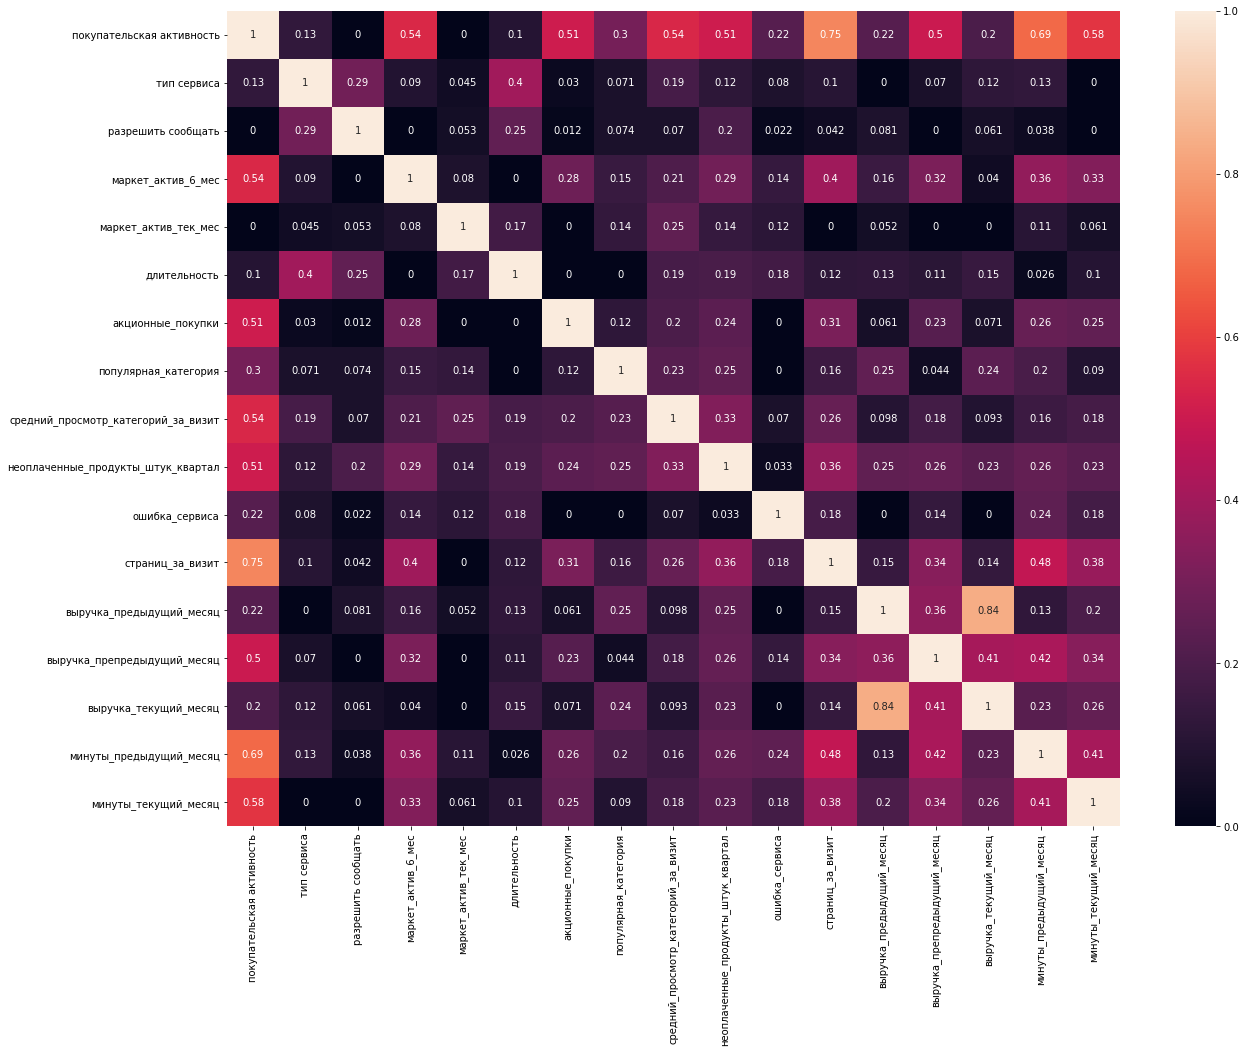

In [41]:
df_correlation = df.drop('id', axis=1)
interval_cols = df_correlation.select_dtypes(include=['int64', 'float64']).columns.tolist()

phik_matrix = df_correlation.phik_matrix(interval_cols=interval_cols)
plt.figure(figsize=(20, 15))
sns.heatmap(phik_matrix, annot=True)
plt.show()

**Вывод:**  
  
Мы вывели матрицу корреляции по всем количественным признакам и теперь можем увидеть все зависимости между целевым признаком и другими.  
  
Целовой признак имеет наиболее высокую корреляцию с следующими признаками:  
  
  - **Страниц_за_визит** - процент корреляции 0.75  
  - **минуты_предыдущий_месяц** - процент корреляции 0.69  
  - **минуты_текущий_месяц** - процент корреляции 0.58  
  - **Средний_просмотр_категорий_за_визит** - процент корреляции 0.54  
  - **Маркет_актив_6_мес** - процент корреляции 0.54  
  - **Акционные_покупки** - процент корреляции 0.51  
  - **Неоплаченные_продукты_штук_квартал** - процент корреляции 0.51  
  - **выручка_предыдущий_месяц** - процент корреляции 0.5  
  
Мультиколлинеарность между признаками не обнаружена.  

## Использование пайплайнов

### Пайплайн с подготовкой данных  
  
Во время подготовки данных будем использовать ColumnTransformer. Количественные и категориальные признаки обработаем в пайплайне раздельно. Для кодирования категориальных признаков будем использовать два кодировщика, для масштабирования количественных — два скейлера.

In [42]:
df_without_id = df.drop('id', axis=1)
df_without_id['покупательская активность'] = df_without_id['покупательская активность'].replace({'Снизилась': 1, 'Прежний уровень': 0})

target_attribute = ['покупательская активность']
features = df_without_id.columns.drop(target_attribute)

num_cols = df_without_id.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_without_id.select_dtypes(include=['object']).columns.tolist()

for i in cat_cols:
    unique_cat_cols = df_without_id[i].unique()
    print(f'Уникальные значения в столбце "{i}": {unique_cat_cols}')

print()
print('Все столбцы с количественными значениями:')
num_cols

Уникальные значения в столбце "тип сервиса": ['премиум' 'стандарт']
,Уникальные значения в столбце "разрешить сообщать": ['да' 'нет']
,Уникальные значения в столбце "популярная_категория": ['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
, 'Кухонная посуда' 'Техника для красоты и здоровья'
, 'Мелкая бытовая техника и электроника']
,
,Все столбцы с количественными значениями:


['покупательская активность',
 'маркет_актив_6_мес',
 'маркет_актив_тек_мес',
 'длительность',
 'акционные_покупки',
 'средний_просмотр_категорий_за_визит',
 'неоплаченные_продукты_штук_квартал',
 'ошибка_сервиса',
 'страниц_за_визит',
 'выручка_предыдущий_месяц',
 'выручка_препредыдущий_месяц',
 'выручка_текущий_месяц',
 'минуты_предыдущий_месяц',
 'минуты_текущий_месяц']

**Создадим первый пайплайн с обработкой данных. Зафиксируем значения random_state и test_size и разделим датафрейм на тренировочные и тестовую выборки.**

In [43]:
RANDOM_STATE = 77
TEST_SIZE = 0.25

X_train, X_test, y_train, y_test = train_test_split(
    df_without_id.drop(target_attribute, axis=1),
    df_without_id[target_attribute],
    random_state=RANDOM_STATE,
    test_size=TEST_SIZE,
    stratify = df_without_id[target_attribute]
)

ohe_cols = ['разрешить сообщать', 'популярная_категория']
ord_cols = ['тип сервиса']
num_cols = ['маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 
            'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 
            'ошибка_сервиса', 'страниц_за_визит', 'минуты_предыдущий_месяц', 'минуты_текущий_месяц']

ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='error')
        )
    ]
)

ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',  
            OrdinalEncoder(
                categories=[
                    ['премиум', 'стандарт'], 
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_cols),
        ('ord', ord_pipe, ord_cols),
        ('num', MinMaxScaler(), num_cols)
    ], 
    remainder='passthrough'
) 

data_preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('ohe',
                                 Pipeline(steps=[('simpleImputer_ohe',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first'))]),
                                 ['разрешить сообщать',
                                  'популярная_категория']),
                                ('ord',
                                 Pipeline(steps=[('simpleImputer_before_ord',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ord',
                                                  OrdinalEncoder(categories=...
                                                 ('simpleImputer_after_ord',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['тип сервиса']),
                                ('num', MinMaxScaler(),
                                 ['маркет_актив_6_мес', 'маркет_актив_тек_мес',
                                  'длительность', 'акционные_покупки',
                                  'средний_просмотр_категорий_за_визит',
                                  'неоплаченные_продукты_штук_квартал',
                                  'ошибка_сервиса', 'страниц_за_визит',
                                  'минуты_предыдущий_месяц',
                                  'минуты_текущий_месяц'])])

In [44]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
) 

Мы создали пайплайн с подготовкой данных и поместили его в итоговый вместе с моделью. Теперь создадим словарь с несколькими моделями и укажем гиперпараметры.

In [45]:
param_grid = [
    {
        # словарь для модели KNeighborsClassifier() 
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 6),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        # словарь для модели DecisionTreeClassifier()
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 10),
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        # словарь для модели LogisticRegression()
        'models': [LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', penalty='l1')],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']
    },
    {
        # словарь для модели SVC()
        'models': [SVC(random_state=RANDOM_STATE, probability=True)],
        'models__kernel': ('sigmoid', 'linear', 'rbf'),
        'preprocessor__num': [StandardScaler(), 'passthrough']
    }
]

Для анализа моделей будем использовать метрику ROC_AUC, поскольку она лучше справляется с дисбалансом классов.

In [46]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

randomized_search.fit(X_train, y_train)

print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)

/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
,  y = column_or_1d(y, warn=True)
,/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
,  y = column_or_1d(y, warn=True)
,/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
,  y = column_or_1d(y, warn=True)
,/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for ex

Лучшая модель и её параметры:
,
, Pipeline(steps=[('preprocessor',
,                 ColumnTransformer(remainder='passthrough',
,                                   transformers=[('ohe',
,                                                  Pipeline(steps=[('simpleImputer_ohe',
,                                                                   SimpleImputer(strategy='most_frequent')),
,                                                                  ('ohe',
,                                                                   OneHotEncoder(drop='first'))]),
,                                                  ['разрешить сообщать',
,                                                   'популярная_категория']),
,                                                 ('ord',
,                                                  Pipeline(steps=[('simpleImputer_before_ord',
,                                                                   SimpleImputer(strategy='most_frequent')),
,                       

/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
,  y = column_or_1d(y, warn=True)


In [47]:
probabilities = randomized_search.predict_proba(X_test)

probabilities_1 = probabilities[:, 1]
y_test_roc_auc = roc_auc_score(y_test, probabilities_1)

print(f'Метрика ROC-AUC на тестовой выборке для класса 1: {y_test_roc_auc}')

Метрика ROC-AUC на тестовой выборке для класса 1: 0.8869354838709677


### Вывод по лучшей модели  
  
Самой лучшей моделью оказалась LogisticRegression с гиперпараметрами (C=1, penalty='l1', random_state=77, solver='liblinear').  
Ее качество на тренировочной выборке составляет 0.91, на тестовой 0.85 и при классовом предсказании она показала результат 0.89. Это довольно высокие показатели, значит модель редко делает ошибки, а значит ее можно использовать для предсказания покупательской активности.

## Анализ важности признаков

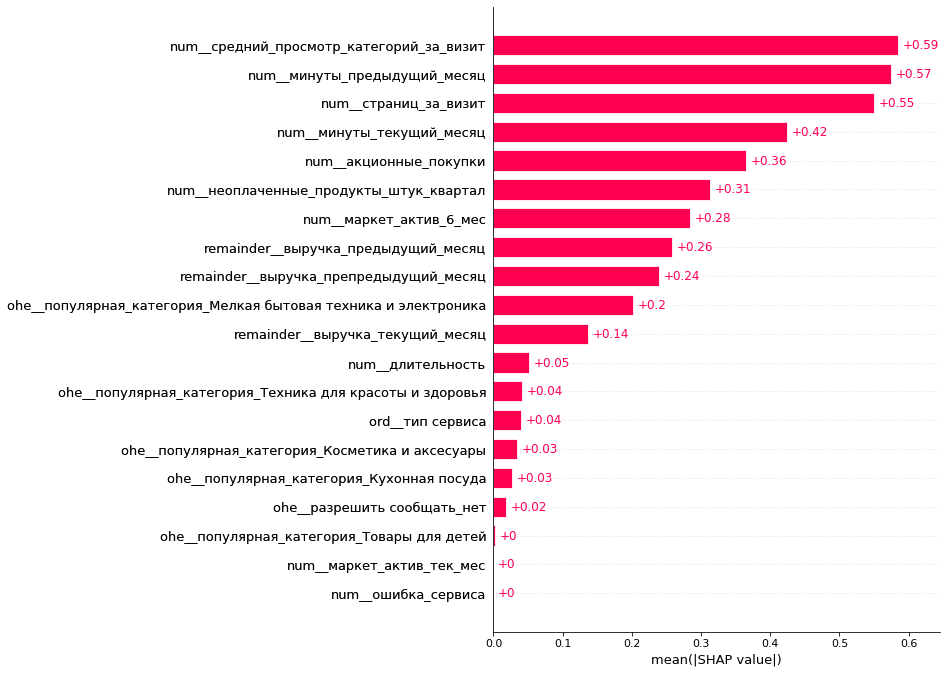

In [48]:
X_train_2 = pipe_final.named_steps['preprocessor'].fit_transform(X_train)
X_test_2 = pipe_final.named_steps['preprocessor'].transform(X_test)

explainer = shap.Explainer(randomized_search.best_estimator_.named_steps['models'], X_train_2)

feature_names = pipe_final.named_steps['preprocessor'].get_feature_names_out()

X_test_2 = pd.DataFrame(X_test_2, columns=feature_names)
shap_values = explainer(X_test_2)

shap.plots.bar(shap_values, max_display=50)

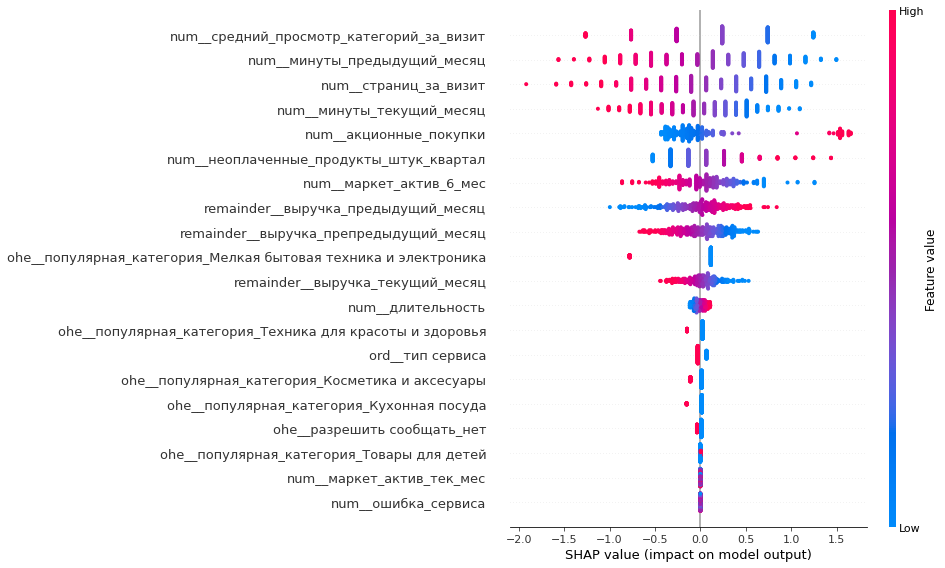

In [49]:
shap.plots.beeswarm(shap_values, max_display=250)

**Вывод:**  
  
Мы вывели 2 графика, показывающих влияние признаков на целевой.  
  
Признаки, имеющие положительное значение SHAP на втором графике повышают вероятность снижения активности клиента, а признаки, имеющие отрицательное значение SHAP наоборот понижают вероятность снижения активности.
  
  
Судя по показателям почти никакого влияния не оказывают такие признаки, как Популярная_категория_Товары для детей, Макрет_актив_тек_мес и Ошибка_сервиса. Все эти 3 признака влияют на целевой меньше чем на 0.01. Соответственно их можно считайть бесполезными.    
  
**Более высокое влияние на целевой признак оказывают следующие признаки:**  
  
 - **Средний_просмотр_категорий_за_визит** - Данный признак показывает то, сколько различных категорий товаров пользователь просматривал в среднем за визит за последний месяц. Показатель его влияния на целевой признак равен 0.59 и на втором графике видно, что он имеет отрицательное значение.  
 - **минуты_предыдущий_месяц** - Этот признак показывает, сколько пользователь проводил времени на сайте за предыдущий месяц. Показатель влияния этого признака на целевой составляет 0.57. Значение SHAP так же отрицательное.  
 - **Страниц_за_визит** - Этот признак показывает, сколько пользователь просмотрел страниц за один визит. Показатель этого признака равен 0.55. У этого признака самое большое отрицательное значение SHAP.  
 - **минуты_текущий_месяц** - Этот признак показывает , сколько пользователь проводил времени на сайте за текущий месяц. Показатель влияния этого признака на целевой составляет 0.42. Значение SHAP отрицательное.  

## Сегментация покупателей

In [50]:
display(df.shape)
df.head()

(1296, 18)

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минуты_предыдущий_месяц,минуты_текущий_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10


In [51]:
display(df_money.shape)
df_money.head()

(1296, 2)

,id,прибыль
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21
5,215353,3.95


In [52]:
df = df.merge(df_money, on='id', how='inner')
display(df.shape)
df.head()

(1296, 19)

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минуты_предыдущий_месяц,минуты_текущий_месяц,прибыль
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10,4.16
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13,3.13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13,4.87
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11,4.21
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10,3.95


На этапе исследовательского анализа мы выяснили, что самыми популярными категориями являются Товары для детей и Домашний текстиль. Так что дальше будем работать с данным сегментом покупателей.  
  
Проведем графическое и аналитическое исследование групп покупателей и сделаем предложения по работе с сегментом для увеличения покупательской активности.

In [53]:
df_childrens_products = df[df['популярная_категория'] == 'Товары для детей']
display(df_childrens_products.shape)
df_childrens_products.head()

(329, 19)

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минуты_предыдущий_месяц,минуты_текущий_месяц,прибыль
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10,4.16
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13,4.87
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11,4.21
6,215355,Снизилась,стандарт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4,3263.0,4749.0,3772.6,12,10,5.26
12,215363,Снизилась,стандарт,нет,4.9,4,923,0.29,Товары для детей,6,0,3,1,6010.0,4633.0,6128.3,8,5,1.83


In [54]:
df_home_textiles = df[df['популярная_категория'] == 'Домашний текстиль']
display(df_home_textiles.shape)
df_home_textiles.head()

(250, 19)

,id,покупательская активность,тип сервиса,разрешить сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минуты_предыдущий_месяц,минуты_текущий_месяц,прибыль
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13,3.13
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10,3.95
8,215358,Снизилась,стандарт,да,4.7,4,450,0.13,Домашний текстиль,4,2,6,4,3488.0,4727.0,4209.5,14,10,3.06
11,215362,Снизилась,премиум,да,4.2,4,438,0.74,Домашний текстиль,3,4,6,4,4314.0,4765.0,4447.9,13,13,3.49
13,215364,Снизилась,премиум,да,4.3,4,708,0.98,Домашний текстиль,3,3,3,3,5795.5,4942.0,5484.8,11,9,2.67


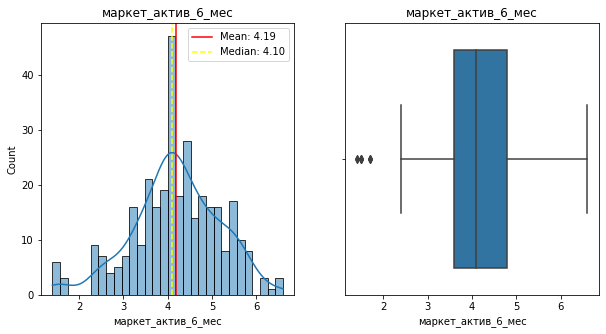

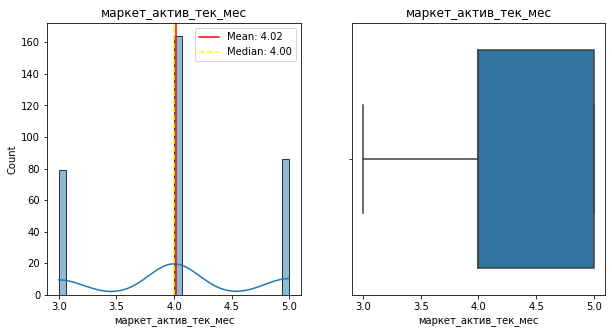

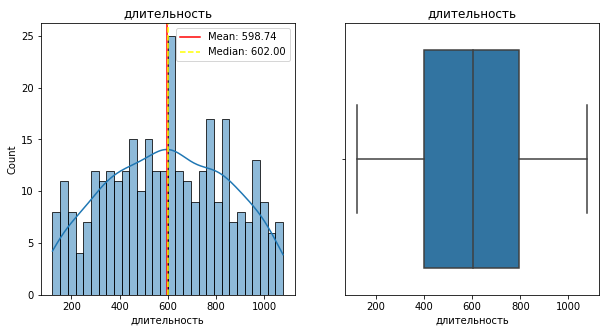

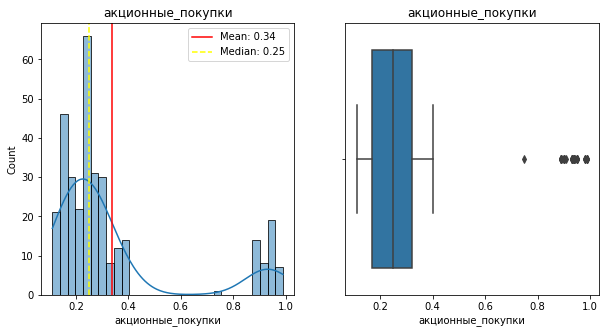

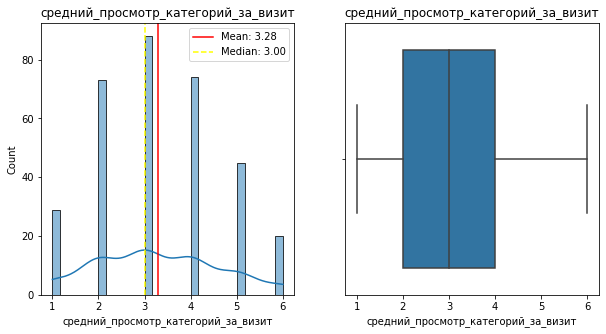

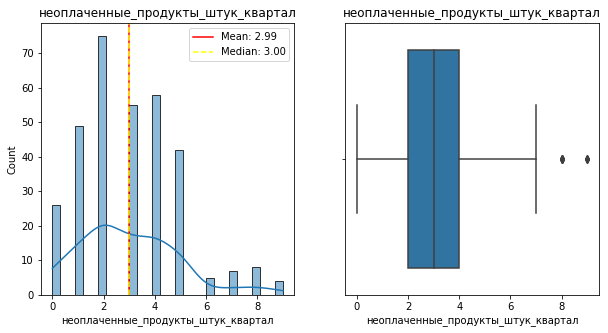

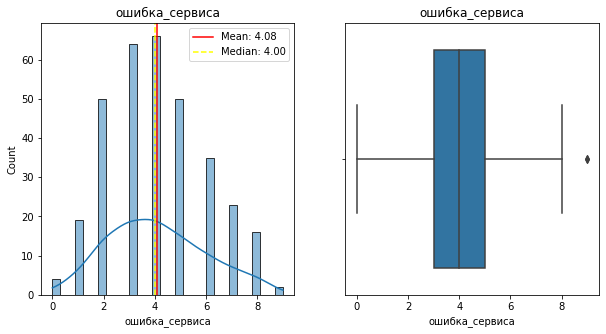

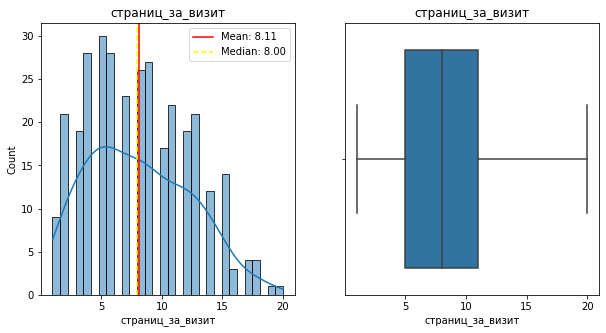

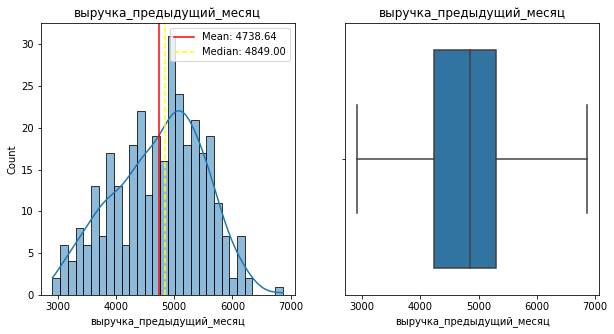

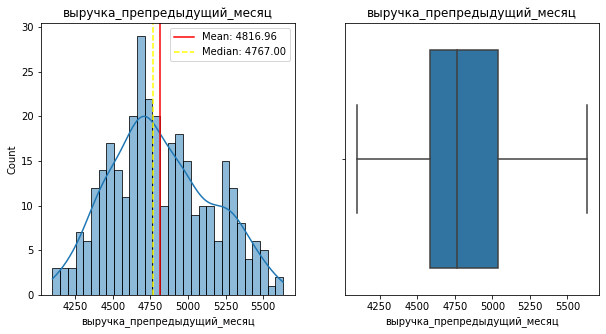

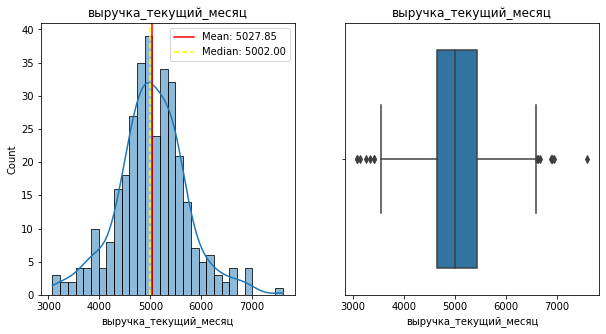

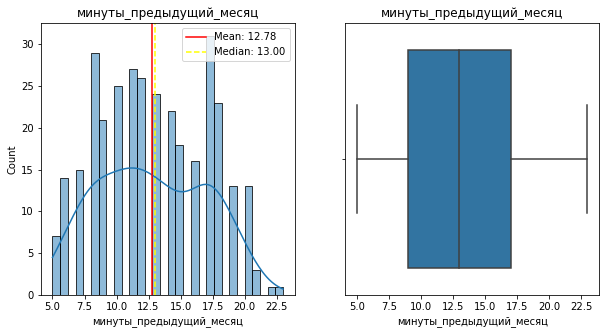

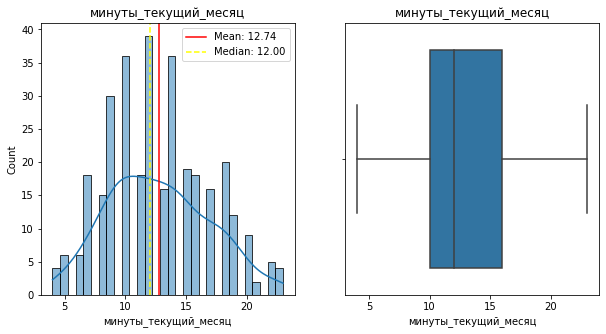

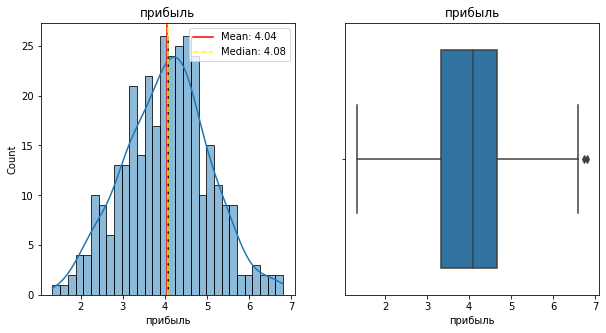

In [55]:
df_visualization(df_childrens_products)

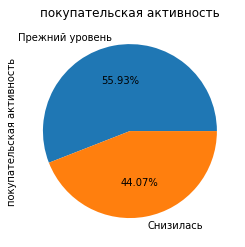

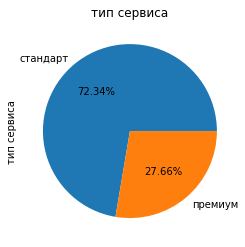

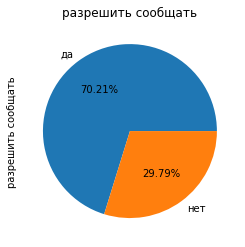

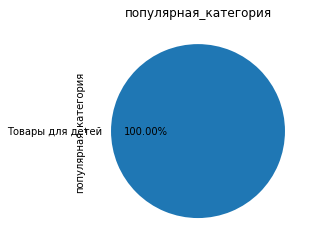

In [56]:
df_visualization2(df_childrens_products)

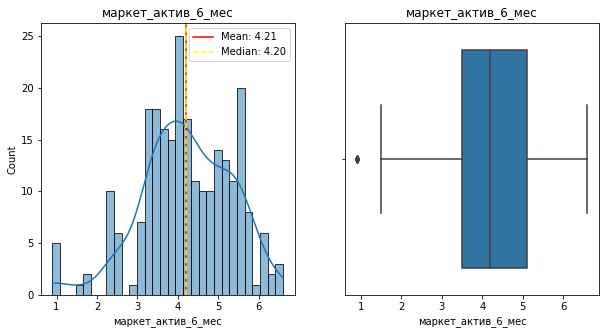

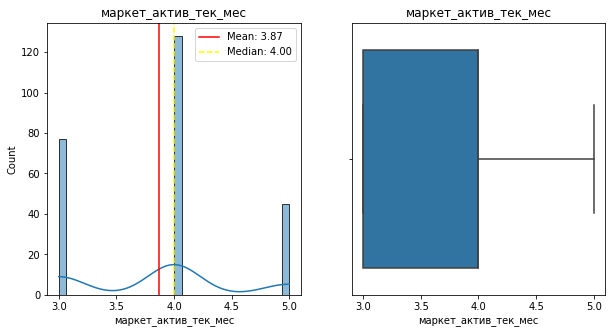

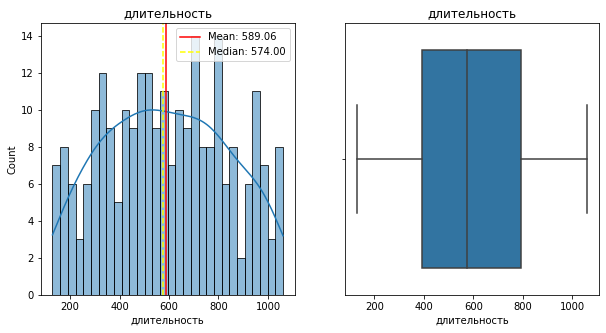

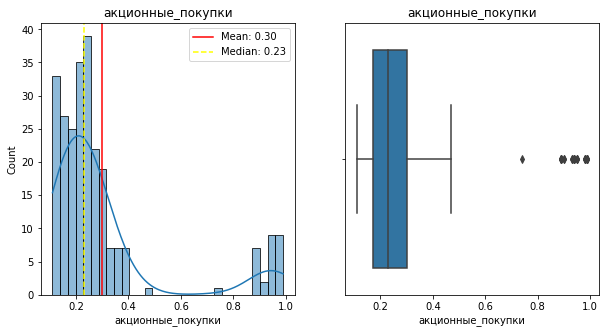

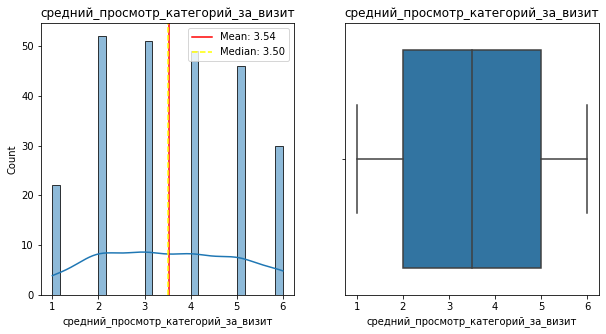

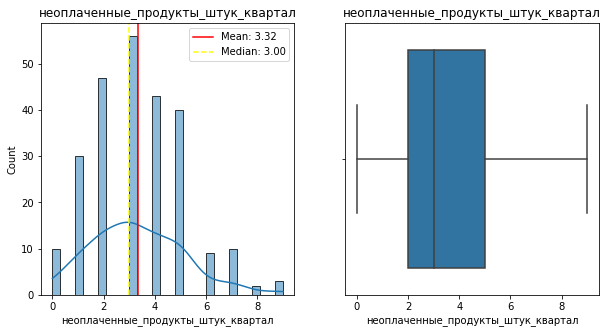

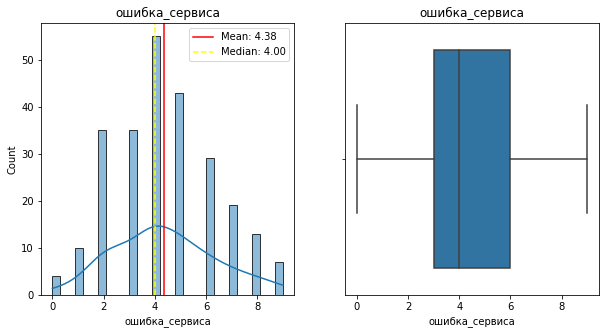

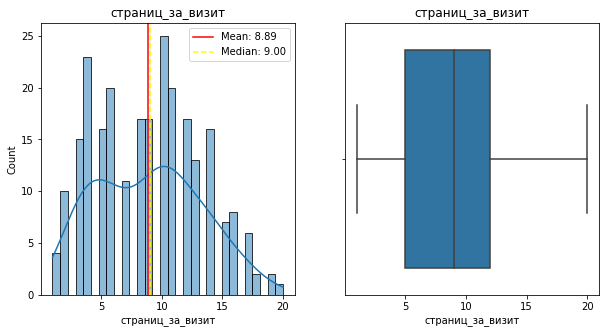

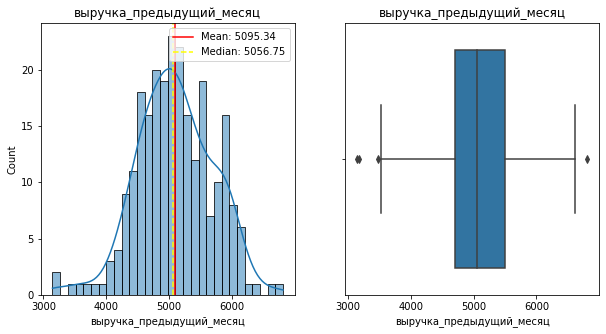

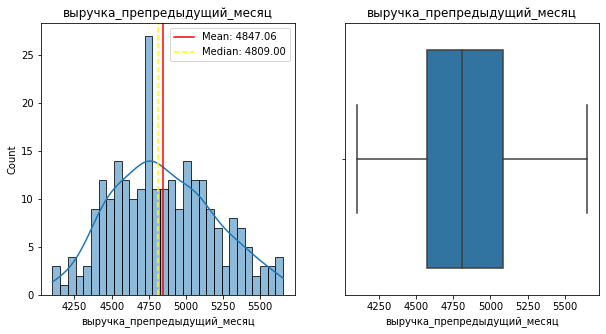

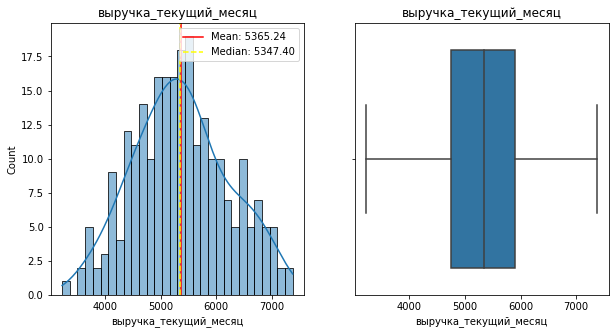

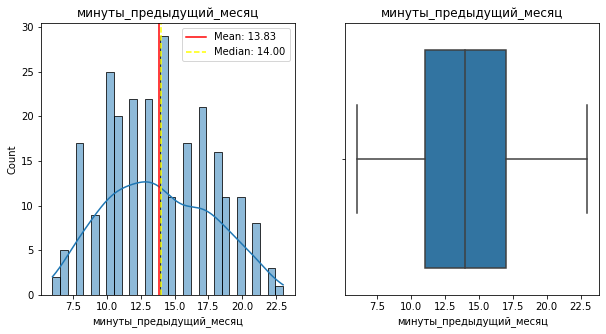

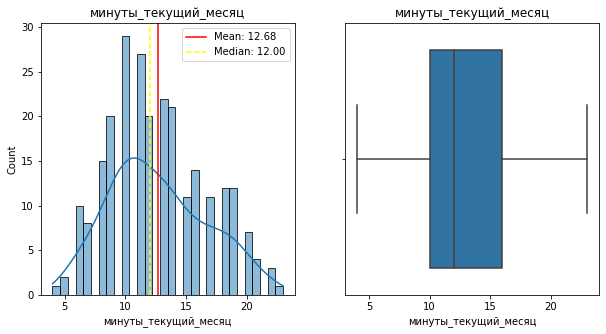

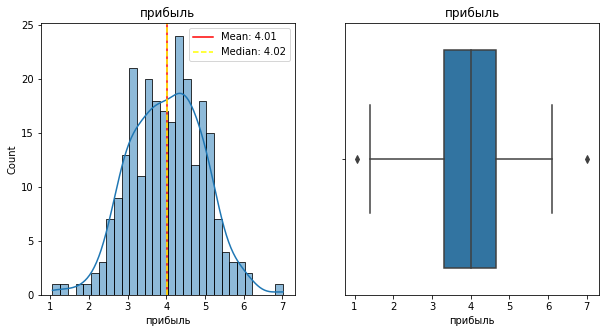

In [57]:
df_visualization(df_home_textiles)

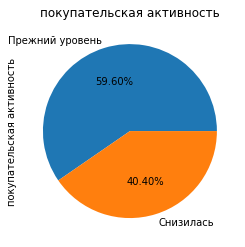

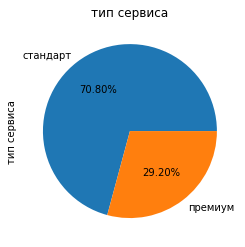

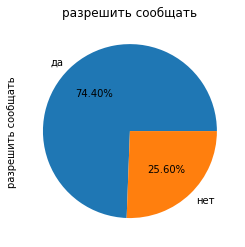

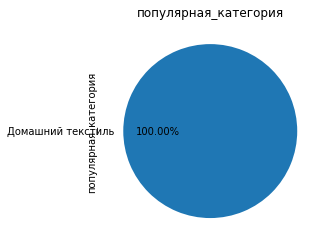

In [58]:
df_visualization2(df_home_textiles)

**Вывод по сегментации покупателей:**  
  
Проанализировав графики обоих сегментов мы видим, что покупательская активность чаще снижается, чем в общем датафрейме, а если точнее, то в общей выборке в 38% случаев покупательская активность снизилась, а в самых популярных категориях Товаря для детей и Домашний текстиль покупательская активность снизилась в 44% и 40% случаев соответственно.  
  
**Увеличить покупательскую активность в данных категориях покупателей можно следующими методами:**  
  - Для категории "Товары для детей" можно проводить сезонные распродажы, к примеру, к началу учебного года. Так же можно реализовать программу бонусов за покупки, делать дополнительные скидки в праздники и таким образом покупательская активность может возрасти.  
  - С категорией "Домашний текстиль" почти тоже самое, можно проводить распродажы в зависимости от сезона и так же предоставлять скидки, например, на наборы товаров, чтобы заинтересовать клиентов покупать большее количество товаров.

## Итоговый вывод по исследованию

**Описание задачи:**  
  
У нас была задача разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность. Необходимо было построить модель, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца. Используя данные модели и данные о прибыльности клиентов, нужно было выделить сегменты покупателей и разработать для них персонализированные предложения.  
  
В исследовании мы использовали 4 таблицы с данными:  
 - В первой таблице была информация о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении. 
 - Вторая таблица включала в себя данные о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.  
 - В третьей таблицы были данные о времени (в минутах), которое покупатель провёл на сайте в течение периода.  
 - И последняя таблица содержала данные о среднемесячной прибыли покупателя за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.  
  
В данных остутствовали пропуски и так же не было дубликатов. Во всех таблицах была информация о 1300 пользователях. Было несколько опечаток, которые в итоге были исправленны и все таблицы объединены в один датафрейм.  
  
**Лучшая модель:**  
  
Лучшей моделью получилась Логистическая регрессия с такими гиперпараметрами как, random_state=77, C=1, penalty='l1', solver='liblinear'. Показатели метрик качества модели на тренировочной и тестовой выборке были равны 0.89.  
  
Наиболее влиятельными признаками на покупательскую активность оказались **"Средний_просмотр_категорий_за_визит"**, **"минуты_предыдущий_месяц"**, **"Страниц_за_визит"**, **"минуты_текущий_месяц"**.  
  
**Выводы и дополнительные предложения для выбранного сегмента покупателей:**  
  
Проанализировав графики обоих сегментов мы видим, что покупательская активность чаще снижается, чем в общем датафрейме, а если точнее, то в общей выборке в 38% случаев покупательская активность снизилась, а в самых популярных категориях Товаря для детей и Домашний текстиль покупательская активность снизилась в 44% и 40% случаев соответственно.  
  
Увеличить покупательскую активность в данных категориях покупателей можно следующими методами:  
  - Для категории "Товары для детей" можно проводить сезонные распродажы, к примеру, к началу учебного года. Так же можно реализовать программу бонусов за покупки, делать дополнительные скидки в праздники и таким образом покупательская активность может возрасти.  
  - С категорией "Домашний текстиль" почти тоже самое, можно проводить распродажы в зависимости от сезона и так же предоставлять скидки, например, на наборы товаров, чтобы заинтересовать клиентов покупать большее количество товаров.